In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Clean datasets/Typhoid_Surveillance_Clean.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (39834, 10)


,Patient_ID,Screening_Date,Enrollment_Date,Site,Province,City,Location,Case_Status,Blood_Culture_Result,TCV_Status
0,PK-SIH-00001,2020-10-05,2020-10-06,SIH,Federal,Islamabad,OPD,Suspected,NBG,Unknown
1,PK-SIH-00002,2020-10-06,2020-10-06,SIH,Federal,Islamabad,OPD,Suspected,ST,No
2,PK-SIH-00003,2020-10-06,2020-10-06,SIH,Federal,Islamabad,Inpatient,Confirmed,NBG,No
3,PK-NICH-00001,2020-10-06,2020-10-09,NICH,Sindh,Karachi,OPD,Suspected,NBG,No
4,PK-NICH-00002,2020-10-06,2020-10-09,NICH,Sindh,Karachi,OPD,Confirmed,NBG,Unknown


In [4]:
df["Screening_Date"] = pd.to_datetime(df["Screening_Date"])

print("Start date:", df["Screening_Date"].min())
print("End date:", df["Screening_Date"].max())

Start date: 2020-10-05 00:00:00
End date: 2025-07-28 00:00:00


In [5]:
confirmed_df = df[
    df["Case_Status"].str.lower() == "confirmed"
].copy()

print("Total confirmed cases:", len(confirmed_df))

Total confirmed cases: 2720


In [6]:
typhoid_monthly = (
    confirmed_df
    .set_index("Screening_Date")
    .resample("MS")
    .size()
    .reset_index(name="Cases")
)

typhoid_monthly.head(10)

,Screening_Date,Cases
0,2020-10-01,6
1,2020-11-01,13
2,2020-12-01,17
3,2021-01-01,27
4,2021-02-01,39
5,2021-03-01,45
6,2021-04-01,31
7,2021-05-01,31
8,2021-06-01,39
9,2021-07-01,50


In [7]:
month_range = pd.date_range(
    start=typhoid_monthly["Screening_Date"].min(),
    end=typhoid_monthly["Screening_Date"].max(),
    freq="MS"
)

typhoid_monthly = (
    typhoid_monthly
    .set_index("Screening_Date")
    .reindex(month_range, fill_value=0)
    .rename_axis("Screening_Date")
    .reset_index()
)

typhoid_monthly.head(10)

,Screening_Date,Cases
0,2020-10-01,6
1,2020-11-01,13
2,2020-12-01,17
3,2021-01-01,27
4,2021-02-01,39
5,2021-03-01,45
6,2021-04-01,31
7,2021-05-01,31
8,2021-06-01,39
9,2021-07-01,50


In [8]:
typhoid_prophet = typhoid_monthly.rename(
    columns={
        "Screening_Date": "ds",
        "Cases": "y"
    }
)

typhoid_prophet.head()

,ds,y
0,2020-10-01,6
1,2020-11-01,13
2,2020-12-01,17
3,2021-01-01,27
4,2021-02-01,39


In [9]:
print("Number of monthly rows:", len(typhoid_prophet))
print("Start month:", typhoid_prophet["ds"].min())
print("End month:", typhoid_prophet["ds"].max())

print("\nLast 5 months:")
print(typhoid_prophet.tail())

Number of monthly rows: 58
Start month: 2020-10-01 00:00:00
End month: 2025-07-01 00:00:00

Last 5 months:
           ds   y
53 2025-03-01  37
54 2025-04-01  29
55 2025-05-01  39
56 2025-06-01  32
57 2025-07-01  25


In [10]:
train_size = int(len(typhoid_prophet) * 0.80)

train = typhoid_prophet.iloc[:train_size].copy()
test = typhoid_prophet.iloc[train_size:].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(train["ds"].min(), "to", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "to", test["ds"].max())

Training rows: 46
Testing rows: 12

Training period:
2020-10-01 00:00:00 to 2024-07-01 00:00:00

Testing period:
2024-08-01 00:00:00 to 2025-07-01 00:00:00


In [11]:
typhoid_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

print("Monthly Typhoid Prophet model created successfully.")

Monthly Typhoid Prophet model created successfully.


In [12]:
typhoid_model.fit(train)

print("Monthly Typhoid Prophet model trained successfully.")

Monthly Typhoid Prophet model trained successfully.


In [13]:
forecast_test = typhoid_model.predict(
    test[["ds"]]
)

forecast_test[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head(12)

,ds,yhat,yhat_lower,yhat_upper
0,2024-08-01,100.855991,84.575300,118.142349
1,2024-09-01,94.349736,76.943586,111.018904
2,2024-10-01,44.612456,29.390954,61.537530
3,2024-11-01,46.172543,28.979401,61.532487
4,2024-12-01,47.539612,31.415369,63.434391
5,2025-01-01,62.400568,46.428696,79.649139
6,2025-02-01,72.089069,55.633934,88.130406
7,2025-03-01,64.372715,46.905214,80.114052
8,2025-04-01,56.175830,38.653371,72.568101
9,2025-05-01,84.790146,68.654873,100.237568


In [14]:
comparison = test[["ds", "y"]].copy()

comparison["Predicted Cases"] = forecast_test["yhat"].values

comparison

,ds,y,Predicted Cases
46,2024-08-01,45,100.855991
47,2024-09-01,42,94.349736
48,2024-10-01,42,44.612456
49,2024-11-01,32,46.172543
50,2024-12-01,23,47.539612
51,2025-01-01,37,62.400568
52,2025-02-01,29,72.089069
53,2025-03-01,37,64.372715
54,2025-04-01,29,56.175830
55,2025-05-01,39,84.790146


In [15]:
y_actual = comparison["y"].values
y_predicted = comparison["Predicted Cases"].values

monthly_mae = mean_absolute_error(
    y_actual,
    y_predicted
)

print("Monthly Typhoid MAE:", monthly_mae)

Monthly Typhoid MAE: 34.69115113521047


In [16]:
monthly_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_predicted
    )
)

print("Monthly Typhoid RMSE:", monthly_rmse)

Monthly Typhoid RMSE: 38.247050959826865


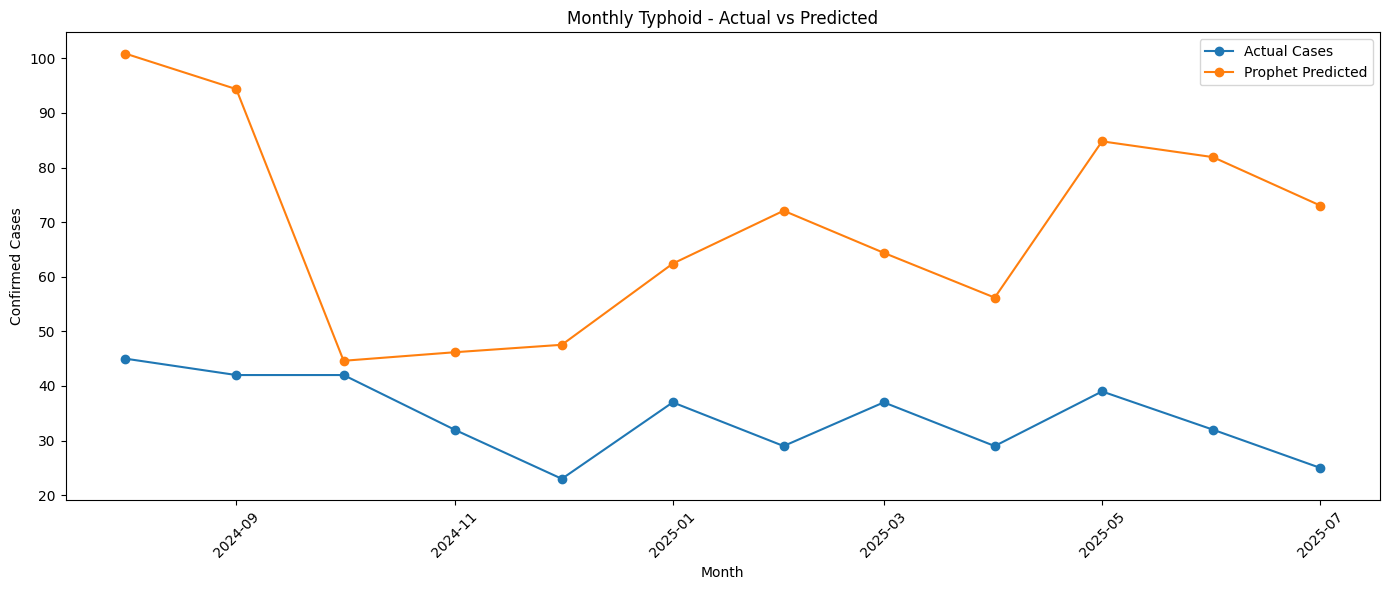

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["ds"],
    comparison["y"],
    marker="o",
    label="Actual Cases"
)

plt.plot(
    comparison["ds"],
    comparison["Predicted Cases"],
    marker="o",
    label="Prophet Predicted"
)

plt.title("Monthly Typhoid - Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Confirmed Cases")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
from prophet import Prophet

typhoid_model_v3 = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=0.1,
    n_changepoints=5
)

typhoid_model_v3.fit(train)

print("Prophet V3 trained successfully.")

Prophet V3 trained successfully.


In [19]:
forecast_v3 = typhoid_model_v3.predict(
    test[["ds"]]
)

comparison_v3 = test[["ds", "y"]].copy()

comparison_v3["Predicted Cases"] = (
    forecast_v3["yhat"].values
)

comparison_v3

,ds,y,Predicted Cases
46,2024-08-01,45,65.366954
47,2024-09-01,42,66.025835
48,2024-10-01,42,66.663461
49,2024-11-01,32,67.322342
50,2024-12-01,23,67.959968
51,2025-01-01,37,68.618849
52,2025-02-01,29,69.277730
53,2025-03-01,37,69.872848
54,2025-04-01,29,70.531729
55,2025-05-01,39,71.169355


In [20]:
mae_v3 = mean_absolute_error(
    comparison_v3["y"],
    comparison_v3["Predicted Cases"]
)

print("Prophet V3 MAE:", mae_v3)

Prophet V3 MAE: 34.591930626786784


In [21]:
rmse_v3 = np.sqrt(
    mean_squared_error(
        comparison_v3["y"],
        comparison_v3["Predicted Cases"]
    )
)

print("Prophet V3 RMSE:", rmse_v3)

Prophet V3 RMSE: 35.55644103484341


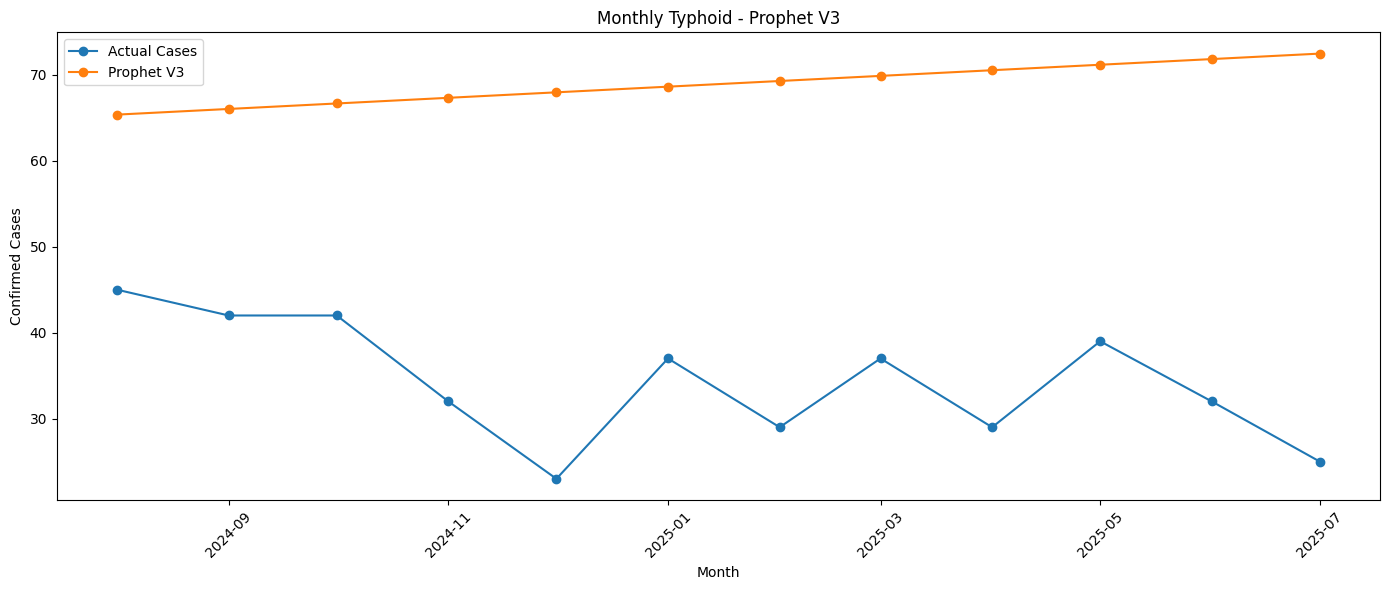

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_v3["ds"],
    comparison_v3["y"],
    marker="o",
    label="Actual Cases"
)

plt.plot(
    comparison_v3["ds"],
    comparison_v3["Predicted Cases"],
    marker="o",
    label="Prophet V3"
)

plt.title("Monthly Typhoid - Prophet V3")
plt.xlabel("Month")
plt.ylabel("Confirmed Cases")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
from prophet import Prophet

typhoid_model_v4 = Prophet(
    growth="flat",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

typhoid_model_v4.fit(train)

print("Prophet V4 trained successfully.")

Prophet V4 trained successfully.


In [24]:
forecast_v4 = typhoid_model_v4.predict(
    test[["ds"]]
)

comparison_v4 = test[["ds", "y"]].copy()

comparison_v4["Predicted Cases"] = (
    forecast_v4["yhat"].values
)

comparison_v4

,ds,y,Predicted Cases
46,2024-08-01,45,50.172217
47,2024-09-01,42,50.172217
48,2024-10-01,42,50.172217
49,2024-11-01,32,50.172217
50,2024-12-01,23,50.172217
51,2025-01-01,37,50.172217
52,2025-02-01,29,50.172217
53,2025-03-01,37,50.172217
54,2025-04-01,29,50.172217
55,2025-05-01,39,50.172217


In [25]:
mae_v4 = mean_absolute_error(
    comparison_v4["y"],
    comparison_v4["Predicted Cases"]
)

print("Prophet V4 MAE:", mae_v4)

Prophet V4 MAE: 15.838883306666665


In [26]:
rmse_v4 = np.sqrt(
    mean_squared_error(
        comparison_v4["y"],
        comparison_v4["Predicted Cases"]
    )
)

print("Prophet V4 RMSE:", rmse_v4)

Prophet V4 RMSE: 17.226697689664523


In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("SARIMA imported successfully.")

SARIMA imported successfully.


In [28]:
train_series = train.set_index("ds")["y"]

print(train_series.head())
print("\nTraining observations:", len(train_series))

ds
2020-10-01     6
2020-11-01    13
2020-12-01    17
2021-01-01    27
2021-02-01    39
Name: y, dtype: int64

Training observations: 46


In [29]:
sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print("SARIMA model trained successfully.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA model trained successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
sarima_forecast = sarima_result.forecast(
    steps=len(test)
)

sarima_forecast = np.array(sarima_forecast)

print("SARIMA predictions:")
print(sarima_forecast)

SARIMA predictions:
[50.49012617 49.42781254 62.72606579 48.66194205 37.48181549 30.40970413
 36.92028994 38.69712786 34.56102025 58.20501667 47.56574935 41.06392474]


In [31]:
sarima_mae = mean_absolute_error(
    test["y"].values,
    sarima_forecast
)

print("SARIMA MAE:", sarima_mae)

SARIMA MAE: 11.44926556026716


In [32]:
sarima_rmse = np.sqrt(
    mean_squared_error(
        test["y"].values,
        sarima_forecast
    )
)

print("SARIMA RMSE:", sarima_rmse)

SARIMA RMSE: 12.94658918550926


In [33]:
# SARIMA Backtesting

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

series = typhoid_prophet.set_index("ds")["y"]

results = []

# Test three historical 6-month periods
test_points = [40, 46, 52]

for point in test_points:

    train_bt = series.iloc[:point]
    test_bt = series.iloc[point:point + 6]

    model_bt = SARIMAX(
        train_bt,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_bt = model_bt.fit(disp=False)

    forecast_bt = fitted_bt.forecast(
        steps=len(test_bt)
    )

    mae_bt = mean_absolute_error(
        test_bt,
        forecast_bt
    )

    rmse_bt = np.sqrt(
        mean_squared_error(
            test_bt,
            forecast_bt
        )
    )

    results.append({
        "Training Months": point,
        "Testing Months": len(test_bt),
        "MAE": mae_bt,
        "RMSE": rmse_bt
    })

backtest_results = pd.DataFrame(results)

print(backtest_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Li

   Training Months  Testing Months        MAE       RMSE
0               40               6   8.666046   9.509113
1               46               6  11.896343  13.201382
2               52               6  16.780242  17.669873


In [34]:
print("Average Backtesting MAE:",
      backtest_results["MAE"].mean())

print("Average Backtesting RMSE:",
      backtest_results["RMSE"].mean())

Average Backtesting MAE: 12.447543554588
Average Backtesting RMSE: 13.460122895277118


In [35]:
final_sarima = SARIMAX(
    typhoid_prophet.set_index("ds")["y"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(disp=False)

print("Final SARIMA model trained successfully.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final SARIMA model trained successfully.


In [36]:
future_forecast = final_sarima_result.forecast(
    steps=6
)

future_dates = pd.date_range(
    start=typhoid_prophet["ds"].max() + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

future_monthly = pd.DataFrame({
    "Date": future_dates,
    "Predicted Cases": future_forecast.values
})

future_monthly["Predicted Cases"] = (
    future_monthly["Predicted Cases"]
    .clip(lower=0)
    .round()
    .astype(int)
)

future_monthly

,Date,Predicted Cases
0,2025-08-01,32
1,2025-09-01,30
2,2025-10-01,31
3,2025-11-01,21
4,2025-12-01,17
5,2026-01-01,22


In [37]:
import joblib

joblib.dump(
    final_sarima_result,
    "typhoid_sarima_monthly.pkl"
)

print("Final Typhoid SARIMA model saved successfully.")

Final Typhoid SARIMA model saved successfully.
